In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
import pandas as pd

In [5]:
import numpy as np

In [6]:
data=pd.read_csv("Lung Cancer Dataset.csv")

In [7]:
data.isnull().sum()

AGE                       0
GENDER                    0
SMOKING                   0
FINGER_DISCOLORATION      0
MENTAL_STRESS             0
EXPOSURE_TO_POLLUTION     0
LONG_TERM_ILLNESS         0
ENERGY_LEVEL              0
IMMUNE_WEAKNESS           0
BREATHING_ISSUE           0
ALCOHOL_CONSUMPTION       0
THROAT_DISCOMFORT         0
OXYGEN_SATURATION         0
CHEST_TIGHTNESS           0
FAMILY_HISTORY            0
SMOKING_FAMILY_HISTORY    0
STRESS_IMMUNE             0
PULMONARY_DISEASE         0
dtype: int64

In [8]:
data.duplicated().sum()

0

In [9]:
data.head()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,PULMONARY_DISEASE
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0,NO
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0,YES
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0,NO
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0,YES
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0,YES


In [10]:
# Identify categorical variables (those with only 2-3 unique values)
categorical_vars = [col for col in data.columns if data[col].nunique() <= 3]

# Convert categorical variables to the correct type
data[categorical_vars] = data[categorical_vars].astype("category")

# Display types
print(data.dtypes)

AGE                          int64
GENDER                    category
SMOKING                   category
FINGER_DISCOLORATION      category
MENTAL_STRESS             category
EXPOSURE_TO_POLLUTION     category
LONG_TERM_ILLNESS         category
ENERGY_LEVEL               float64
IMMUNE_WEAKNESS           category
BREATHING_ISSUE           category
ALCOHOL_CONSUMPTION       category
THROAT_DISCOMFORT         category
OXYGEN_SATURATION          float64
CHEST_TIGHTNESS           category
FAMILY_HISTORY            category
SMOKING_FAMILY_HISTORY    category
STRESS_IMMUNE             category
PULMONARY_DISEASE         category
dtype: object


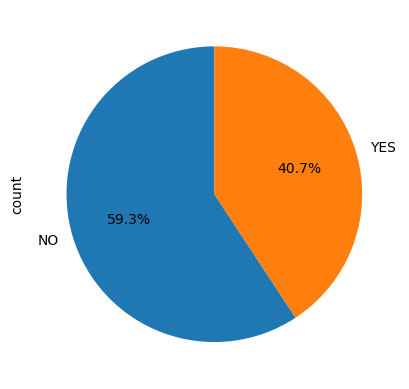

In [11]:
data['PULMONARY_DISEASE'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.show()

In [12]:
import prince

In [13]:
x = data.drop(columns=['PULMONARY_DISEASE'])
y=data['PULMONARY_DISEASE']

In [14]:
from sklearn.model_selection import train_test_split
# Split data into train and test
X_train, X_test, y_train_notscaled, y_test_notscaled = train_test_split(x, y, train_size=.8, random_state=42)
# Check the splits are correct
print(f"Train size: {round(len(X_train) / len(x) * 100)}% \n\
Test size: {round(len(X_test) / len(x) * 100)}%")

Train size: 80% 
Test size: 20%


In [15]:
X_train.dtypes

AGE                          int64
GENDER                    category
SMOKING                   category
FINGER_DISCOLORATION      category
MENTAL_STRESS             category
EXPOSURE_TO_POLLUTION     category
LONG_TERM_ILLNESS         category
ENERGY_LEVEL               float64
IMMUNE_WEAKNESS           category
BREATHING_ISSUE           category
ALCOHOL_CONSUMPTION       category
THROAT_DISCOMFORT         category
OXYGEN_SATURATION          float64
CHEST_TIGHTNESS           category
FAMILY_HISTORY            category
SMOKING_FAMILY_HISTORY    category
STRESS_IMMUNE             category
dtype: object

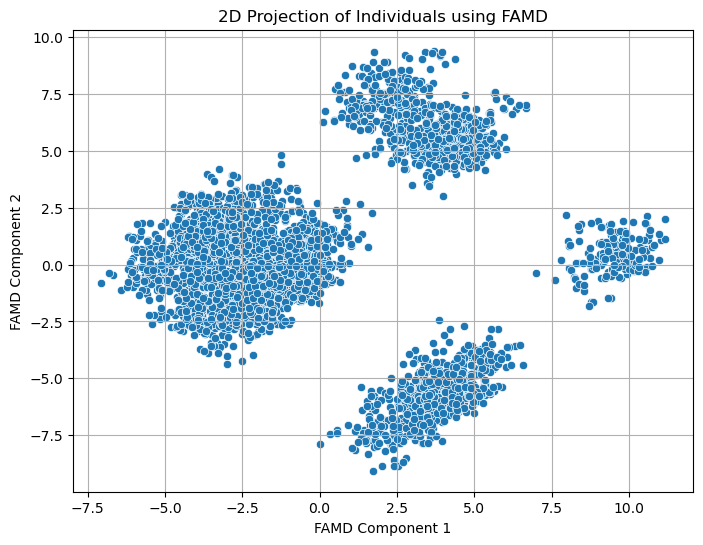

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import prince

# Step 1: Apply FAMD on the dataset
famd = prince.FAMD(n_components=2, random_state=42)
famd = famd.fit(X_train)
X_famd= famd.transform(X_train)

# Step 2: Scatter Plot of FAMD-reduced Data
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_famd[0], y=X_famd[1])
plt.xlabel("FAMD Component 1")
plt.ylabel("FAMD Component 2")
plt.title("2D Projection of Individuals using FAMD")
plt.grid(True)
plt.show()


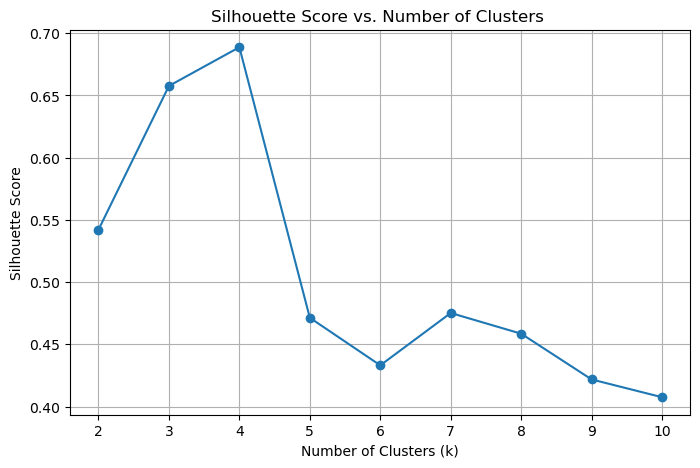

In [17]:
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_famd)
    score = silhouette_score(X_famd, labels)
    silhouette_scores.append(score)

# Step 4: Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. Number of Clusters ")
plt.xticks(K_range)
plt.grid(True)
plt.show()

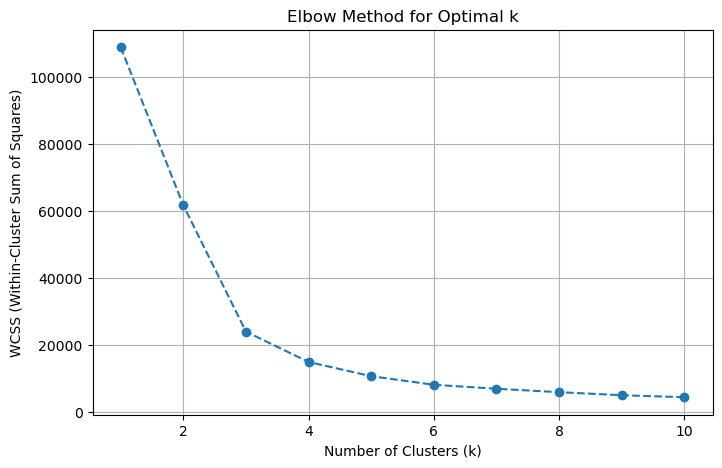

In [18]:
# Define range of clusters to test
range_n_clusters = np.arange(1, 11)  # Testing k from 1 to 10
wcss = []  # Store Within-Cluster Sum of Squares

# Compute WCSS for each k
for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_famd)
    wcss.append(kmeans.inertia_)  # Inertia is the sum of squared distances to centroids

# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, wcss, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

component          0         1
4227       10.574126  2.150854
4676       -1.467227 -0.158796
800         3.458001 -4.226259
3671       -2.371635  1.158752
4193       -1.977794 -2.244654
...              ...       ...
4426       -1.551352 -2.085693
466         5.390410  6.317203
3092       -3.053413 -0.373476
3772       -3.948207  0.014965
860        -1.954540 -2.009557

[4000 rows x 2 columns]


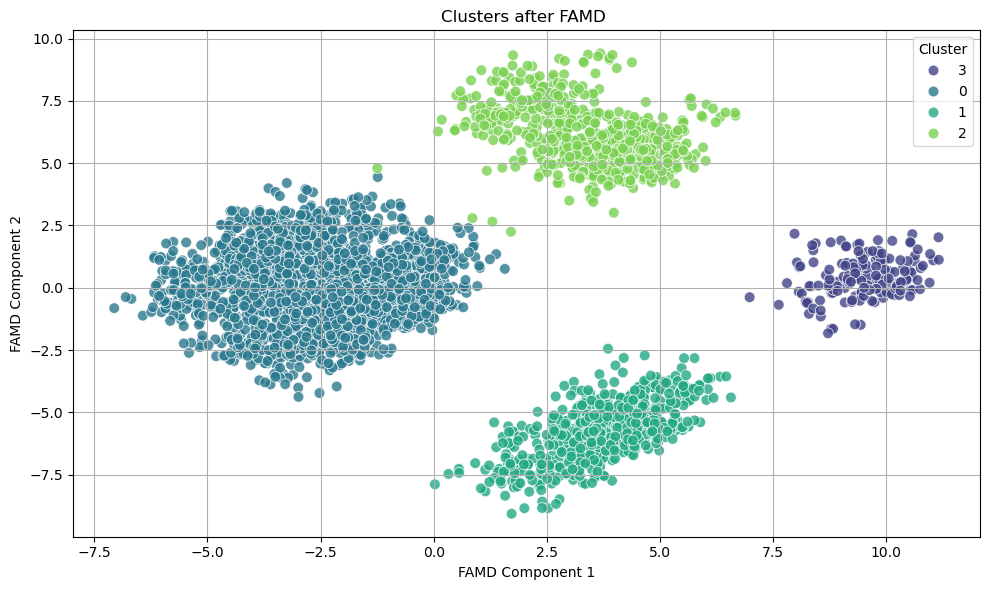

In [19]:
plot_df =  pd.DataFrame(X_famd)
print(plot_df)

# Apply KMeans clustering to the 2D FAMD coordinates
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(plot_df)

# Add the cluster labels to the DataFrame
plot_df['Cluster'] = clusters.astype(str)  # Convert cluster labels to string for better visualization

# Seaborn scatterplot to visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x=0, y=1, hue='Cluster', palette='viridis', s=60, alpha=0.8)

# Add title and labels
plt.title("Clusters after FAMD ")
plt.xlabel("FAMD Component 1")
plt.ylabel("FAMD Component 2")

# Display the legend
plt.legend(title="Cluster")

# Finalize plot
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
famd = prince.FAMD(n_components=2, random_state=42)
famd_test = famd.fit(X_test)
X_test_famd = famd_test.transform(X_test)


X_famd.columns = X_famd.columns.astype(str)
X_test_famd.columns=X_test_famd.columns.astype(str)
# Step 3: Apply KMeans clustering on the transformed training data
kmeans = KMeans(n_clusters=4, random_state=42)
X_train['Cluster'] = kmeans.fit_predict(X_famd)

# Apply the same KMeans model to predict clusters in the test set
X_test['Cluster'] = kmeans.predict(X_test_famd)

# Step 4: Add cluster labels to y_train and y_test
y_train_clustered = pd.concat([y_train_notscaled, X_train['Cluster']], axis=1)
y_test_clustered = pd.concat([y_test_notscaled, X_test['Cluster']], axis=1)



In [21]:
print(X_train["Cluster"].value_counts())

Cluster
0    2520
1     668
2     647
3     165
Name: count, dtype: int64


In [22]:
print(y_train_clustered)

     PULMONARY_DISEASE  Cluster
4227               YES        3
4676               YES        0
800                YES        1
3671               YES        0
4193                NO        0
...                ...      ...
4426                NO        0
466                 NO        2
3092                NO        0
3772                NO        0
860                 NO        0

[4000 rows x 2 columns]


In [23]:
print(X_famd)

component          0         1
4227       10.574126  2.150854
4676       -1.467227 -0.158796
800         3.458001 -4.226259
3671       -2.371635  1.158752
4193       -1.977794 -2.244654
...              ...       ...
4426       -1.551352 -2.085693
466         5.390410  6.317203
3092       -3.053413 -0.373476
3772       -3.948207  0.014965
860        -1.954540 -2.009557

[4000 rows x 2 columns]


In [24]:
print(X_train)

      AGE GENDER SMOKING FINGER_DISCOLORATION MENTAL_STRESS  \
4227   63      1       1                    1             1   
4676   70      1       1                    1             1   
800    60      0       1                    1             1   
3671   40      1       1                    1             0   
4193   40      0       0                    0             0   
...   ...    ...     ...                  ...           ...   
4426   43      1       0                    1             0   
466    52      1       1                    0             1   
3092   75      1       0                    0             0   
3772   43      1       0                    1             0   
860    47      1       1                    1             0   

     EXPOSURE_TO_POLLUTION LONG_TERM_ILLNESS  ENERGY_LEVEL IMMUNE_WEAKNESS  \
4227                     0                 0     49.129678               1   
4676                     1                 0     62.047864               0   
800      

In [25]:
print(X_test)

      AGE GENDER SMOKING FINGER_DISCOLORATION MENTAL_STRESS  \
1501   80      1       1                    0             1   
2586   74      0       1                    1             0   
2653   42      1       1                    0             1   
1055   76      1       0                    1             0   
705    68      0       1                    0             1   
...   ...    ...     ...                  ...           ...   
4711   40      0       1                    1             0   
2313   83      0       1                    0             1   
3214   80      1       0                    1             1   
2732   71      0       1                    0             1   
1926   42      1       1                    1             1   

     EXPOSURE_TO_POLLUTION LONG_TERM_ILLNESS  ENERGY_LEVEL IMMUNE_WEAKNESS  \
1501                     1                 1     42.962294               0   
2586                     0                 0     48.962895               1   
2653     

In [26]:
print(y_test_clustered)

     PULMONARY_DISEASE  Cluster
1501                NO        0
2586                NO        1
2653                NO        1
1055                NO        0
705                 NO        1
...                ...      ...
4711                NO        0
2313                NO        0
3214                NO        2
2732                NO        0
1926               YES        3

[1000 rows x 2 columns]


In [27]:
X_train.dtypes


AGE                          int64
GENDER                    category
SMOKING                   category
FINGER_DISCOLORATION      category
MENTAL_STRESS             category
EXPOSURE_TO_POLLUTION     category
LONG_TERM_ILLNESS         category
ENERGY_LEVEL               float64
IMMUNE_WEAKNESS           category
BREATHING_ISSUE           category
ALCOHOL_CONSUMPTION       category
THROAT_DISCOMFORT         category
OXYGEN_SATURATION          float64
CHEST_TIGHTNESS           category
FAMILY_HISTORY            category
SMOKING_FAMILY_HISTORY    category
STRESS_IMMUNE             category
Cluster                      int32
dtype: object

## Cluster 0

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Separate columns
X_train_features_c0 = X_train[['AGE', 'BREATHING_ISSUE', 'CHEST_TIGHTNESS', 'ENERGY_LEVEL', 
                            'FINGER_DISCOLORATION', 'GENDER', 'LONG_TERM_ILLNESS', 
                            'MENTAL_STRESS', 'OXYGEN_SATURATION', 'SMOKING','EXPOSURE_TO_POLLUTION','THROAT_DISCOMFORT']]

# Identify column types
numeric_features = ['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION']
categorical_features = [col for col in X_train_features_c0.columns if col not in numeric_features]

# Preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
# Filter Cluster 0 for training set
X_cluster0 = X_train[X_train['Cluster'] == 0].drop(columns='Cluster')
y_cluster0 = y_train_notscaled.loc[X_train[X_train['Cluster'] == 0].index]

# Filter Cluster 0 for test set
X_test_c0 = X_test[X_test['Cluster'] == 0].drop(columns='Cluster')
y_test_c0 = y_test_notscaled.loc[X_test_c0.index]


from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [29]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix,precision_score,recall_score
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    # If predictions are probabilities, convert to binary classes ('YES'/'NO')
    if y_pred.ndim == 2:  # If the model output is probability
        y_pred = (y_pred[:, 1] > 0.5).astype(str)  # Convert to binary classes ('YES'/'NO')
    
    # Ensure y_test is in the same format as y_pred
    if isinstance(y_test, pd.DataFrame):  # Check if y_test is a DataFrame
        y_test = y_test.iloc[:, 0]  # Convert DataFrame to Series by selecting the first column
    
    # Now ensure that y_test is in the correct format
    if y_test.dtype == 'int64':
        y_test = y_test.astype(str)  # Convert to string format for consistency
    
    # Compute evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label='YES')
    recall = recall_score(y_test, y_pred, pos_label='YES')
    f1 = f1_score(y_test, y_pred, pos_label='YES')
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

In [30]:
rf_pipeline.fit(X_cluster0,y_cluster0)
print("Random Forest training set")
evaluate_model(rf_pipeline, X_cluster0, y_cluster0)
print("Random Forest test set")
evaluate_model(rf_pipeline, X_test_c0, y_test_c0)

Random Forest training set
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[1819    0]
 [   0  701]]

Random Forest test set
Accuracy: 0.9231
Precision: 0.8854
Recall: 0.8718
F1 Score: 0.8786
Confusion Matrix:
[[394  22]
 [ 25 170]]



## Cluster 1

In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Separate columns
X_train_features_c1 = X_train[['AGE', 'BREATHING_ISSUE', 'CHEST_TIGHTNESS', 'ENERGY_LEVEL', 
                            'FINGER_DISCOLORATION', 'LONG_TERM_ILLNESS', 
                            'ALCOHOL_CONSUMPTION', 'OXYGEN_SATURATION' ,'EXPOSURE_TO_POLLUTION','THROAT_DISCOMFORT','GENDER','SMOKING','FAMILY_HISTORY']]

# Identify column types
numeric_features = ['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION']
categorical_features = [col for col in X_train_features_c1.columns if col not in numeric_features]

# Preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
# Filter Cluster 1 for training set
X_cluster1 = X_train[X_train['Cluster'] == 1].drop(columns='Cluster')
y_cluster1 = y_train_notscaled.loc[X_train[X_train['Cluster'] == 1].index]

# Filter Cluster 1 for test set
X_test_c1 = X_test[X_test['Cluster'] == 1].drop(columns='Cluster')
y_test_c1 = y_test_notscaled.loc[X_test_c1.index]


from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [77]:
lr_pipeline.fit(X_cluster1,y_cluster1)
print("logistic training set")
evaluate_model(lr_pipeline, X_cluster1, y_cluster1)
print("logistic test set")
evaluate_model(lr_pipeline, X_test_c1, y_test_c1)

logistic training set
Accuracy: 0.8922
Precision: 0.8879
Recall: 0.9035
F1 Score: 0.8957
Confusion Matrix:
[[287  39]
 [ 33 309]]

logistic test set
Accuracy: 0.8947
Precision: 0.8947
Recall: 0.9444
F1 Score: 0.9189
Confusion Matrix:
[[ 51  12]
 [  6 102]]



## Cluster 2

In [79]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Separate columns
X_train_features_c2 = X_train[['AGE', 'BREATHING_ISSUE', 'CHEST_TIGHTNESS', 'ENERGY_LEVEL', 
                            'FINGER_DISCOLORATION', 'LONG_TERM_ILLNESS', 
                            'ALCOHOL_CONSUMPTION', 'OXYGEN_SATURATION' ,'EXPOSURE_TO_POLLUTION','THROAT_DISCOMFORT','GENDER','MENTAL_STRESS','IMMUNE_WEAKNESS','SMOKING','SMOKING_FAMILY_HISTORY']]

# Identify column types
numeric_features = ['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION']
categorical_features = [col for col in X_train_features_c2.columns if col not in numeric_features]

# Preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
# Filter Cluster 2 for training set
X_cluster2 = X_train[X_train['Cluster'] == 2].drop(columns='Cluster')
y_cluster2 = y_train_notscaled.loc[X_train[X_train['Cluster'] == 2].index]

# Filter Cluster 2 for test set
X_test_c2 = X_test[X_test['Cluster'] == 2].drop(columns='Cluster')
y_test_c2 = y_test_notscaled.loc[X_test_c2.index]


from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [75]:
rf_pipeline.fit(X_cluster2,y_cluster2)
print("Random Forest training set")
evaluate_model(rf_pipeline, X_cluster2, y_cluster2)
print("Random Forest test set")
evaluate_model(rf_pipeline, X_test_c2, y_test_c2)

Random Forest training set
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[224   0]
 [  0 423]]

Random Forest test set
Accuracy: 0.8012
Precision: 0.9298
Recall: 0.6386
F1 Score: 0.7571
Confusion Matrix:
[[84  4]
 [30 53]]



## cluster 3

In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Separate columns
X_train_features_c3 = X_train[['AGE', 'BREATHING_ISSUE', 'CHEST_TIGHTNESS', 'ENERGY_LEVEL', 
                            'FINGER_DISCOLORATION', 'LONG_TERM_ILLNESS', 
                            'ALCOHOL_CONSUMPTION', 'OXYGEN_SATURATION' ,'EXPOSURE_TO_POLLUTION','THROAT_DISCOMFORT','GENDER']]

# Identify column types
numeric_features = ['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION']
categorical_features = [col for col in X_train_features_c3.columns if col not in numeric_features]

# Preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
# Filter Cluster 3 for training set
X_cluster3 = X_train[X_train['Cluster'] == 3].drop(columns='Cluster')
y_cluster3 = y_train_notscaled.loc[X_train[X_train['Cluster'] == 3].index]

# Filter Cluster 3 for test set
X_test_c3 = X_test[X_test['Cluster'] == 3].drop(columns='Cluster')
y_test_c3 = y_test_notscaled.loc[X_test_c3.index]


from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [36]:
rf_pipeline.fit(X_cluster3,y_cluster3)
print("Random Forest training set")
evaluate_model(rf_pipeline, X_cluster3, y_cluster3)
print("Random Forest test set")
evaluate_model(rf_pipeline, X_test_c3, y_test_c3)

Random Forest training set
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[ 23   0]
 [  0 142]]

Random Forest test set
Accuracy: 0.9362
Precision: 0.9348
Recall: 1.0000
F1 Score: 0.9663
Confusion Matrix:
[[ 1  3]
 [ 0 43]]



## Hyperparameter Tuning

### Cluster 0

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid_c0_simple = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__bootstrap': [True]
}

grid_rf_c0 = GridSearchCV(rf_pipeline, param_grid_c0_simple, cv=3, scoring='accuracy', n_jobs=-1)
grid_rf_c0.fit(X_cluster0, y_cluster0)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['AGE',
                                                                          'ENERGY_LEVEL',
                                                                          'OXYGEN_SATURATION']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['BREATHING_ISSUE',
                                                                          'CHEST_TIGHTNESS',
                                                                          'FINGER_DISCOLORATION',
                                                                          'LONG_TERM_ILLNESS',
                                                                          'ALCOHOL_CONSUMPTION',
                                                                          'EXPOSURE_TO_POLLUTION',
                                                                          'THROAT_DISCOMFORT',
                                                                          'GENDER'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__bootstrap': [True],
                         'classifier__max_depth': [None, 10],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='accuracy')

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Separate columns
X_train_features_c0 = X_train[['AGE', 'BREATHING_ISSUE', 'CHEST_TIGHTNESS', 'ENERGY_LEVEL', 
                            'FINGER_DISCOLORATION', 'GENDER', 'LONG_TERM_ILLNESS', 
                            'MENTAL_STRESS', 'OXYGEN_SATURATION', 'SMOKING','EXPOSURE_TO_POLLUTION','THROAT_DISCOMFORT']]

# Identify column types
numeric_features = ['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION']
categorical_features = [col for col in X_train_features_c0.columns if col not in numeric_features]

# Preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
# Filter Cluster 0 for training set
X_cluster0 = X_train[X_train['Cluster'] == 0].drop(columns='Cluster')
y_cluster0 = y_train_notscaled.loc[X_train[X_train['Cluster'] == 0].index]

# Filter Cluster 0 for test set
X_test_c0 = X_test[X_test['Cluster'] == 0].drop(columns='Cluster')
y_test_c0 = y_test_notscaled.loc[X_test_c0.index]


from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(min_samples_leaf=2, random_state=42))
])

In [42]:
rf_pipeline.fit(X_cluster0,y_cluster0)
print("Random Forest training set")
evaluate_model(rf_pipeline, X_cluster0, y_cluster0)
print("Random Forest test set")
evaluate_model(rf_pipeline, X_test_c0, y_test_c0)

Random Forest training set
Accuracy: 0.9357
Precision: 0.9285
Recall: 0.8331
F1 Score: 0.8782
Confusion Matrix:
[[1774   45]
 [ 117  584]]

Random Forest test set
Accuracy: 0.9247
Precision: 0.8901
Recall: 0.8718
F1 Score: 0.8808
Confusion Matrix:
[[395  21]
 [ 25 170]]



### cluster 1

In [44]:
param_grid_c1_simple = {
    'classifier__C': [0.1, 1, 10],
    'classifier__solver': ['liblinear', 'lbfgs'],
    'classifier__max_iter': [100, 200]
}

grid_lr_c1 = GridSearchCV(lr_pipeline, param_grid_c1_simple, cv=3, scoring='accuracy', n_jobs=-1)
grid_lr_c1.fit(X_cluster1, y_cluster1)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['AGE',
                                                                          'ENERGY_LEVEL',
                                                                          'OXYGEN_SATURATION']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['BREATHING_ISSUE',
                                                                          'CHEST_TIGHTNESS',
                                                                          'FINGER_DISCOLORATION',
                                                                          'GENDER',
                                                                          'LONG_TERM_ILLNESS',
                                                                          'MENTAL_STRESS',
                                                                          'SMOKING',
                                                                          'EXPOSURE_TO_POLLUTION',
                                                                          'THROAT_DISCOMFORT'])])),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.1, 1, 10],
                         'classifier__max_iter': [100, 200],
                         'classifier__solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [81]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Separate columns
X_train_features_c1 = X_train[['AGE', 'BREATHING_ISSUE', 'CHEST_TIGHTNESS', 'ENERGY_LEVEL', 
                            'FINGER_DISCOLORATION', 'LONG_TERM_ILLNESS', 
                            'ALCOHOL_CONSUMPTION', 'OXYGEN_SATURATION' ,'EXPOSURE_TO_POLLUTION','THROAT_DISCOMFORT','GENDER','SMOKING','FAMILY_HISTORY']]

# Identify column types
numeric_features = ['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION']
categorical_features = [col for col in X_train_features_c1.columns if col not in numeric_features]

# Preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
# Filter Cluster 1 for training set
X_cluster1 = X_train[X_train['Cluster'] == 1].drop(columns='Cluster')
y_cluster1 = y_train_notscaled.loc[X_train[X_train['Cluster'] == 1].index]

# Filter Cluster 1 for test set
X_test_c1 = X_test[X_test['Cluster'] == 1].drop(columns='Cluster')
y_test_c1 = y_test_notscaled.loc[X_test_c1.index]


from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=1, solver='liblinear'))
])

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [73]:
lr_pipeline.fit(X_cluster1,y_cluster1)
print("logistic training set")
evaluate_model(lr_pipeline, X_cluster1, y_cluster1)
print("logistic test set")
evaluate_model(lr_pipeline, X_test_c1, y_test_c1)

logistic training set
Accuracy: 0.8922
Precision: 0.8857
Recall: 0.9064
F1 Score: 0.8960
Confusion Matrix:
[[286  40]
 [ 32 310]]

logistic test set
Accuracy: 0.9006
Precision: 0.8957
Recall: 0.9537
F1 Score: 0.9238
Confusion Matrix:
[[ 51  12]
 [  5 103]]



### cluster 2

In [56]:
param_grid_c2_third = {
    'classifier__n_estimators': [100, 150, 200],
    'classifier__max_depth': [5, 15, 25],
    'classifier__min_samples_split': [2, 4],
    'classifier__min_samples_leaf': [1, 3],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__bootstrap': [True]
}

grid_rf_c2_third = GridSearchCV(rf_pipeline, param_grid_c2_third, cv=3, scoring='accuracy', n_jobs=-1)
grid_rf_c2_third.fit(X_cluster2, y_cluster2)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['AGE',
                                                                          'ENERGY_LEVEL',
                                                                          'OXYGEN_SATURATION']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['BREATHING_ISSUE',
                                                                          'CHEST_TIGHTNESS',
                                                                          'FINGER_DISCOLORATION',
                                                                          'LONG_TERM_ILLNESS',
                                                                          'ALCOHOL_CONSUMPTION',
                                                                          'EXPOSURE_TO_POLLUTION',
                                                                          'THROAT_DISCOMFORT...
                                                               max_depth=15,
                                                               min_samples_leaf=3,
                                                               min_samples_split=3,
                                                               n_estimators=150,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__bootstrap': [True],
                         'classifier__max_depth': [5, 15, 25],
                         'classifier__max_features': ['sqrt', 'log2'],
                         'classifier__min_samples_leaf': [1, 3],
                         'classifier__min_samples_split': [2, 4],
                         'classifier__n_estimators': [100, 150, 200]},
             scoring='accuracy')

In [82]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Separate columns
X_train_features_c2 = X_train[['AGE', 'BREATHING_ISSUE', 'CHEST_TIGHTNESS', 'ENERGY_LEVEL', 
                            'FINGER_DISCOLORATION', 'LONG_TERM_ILLNESS', 
                            'ALCOHOL_CONSUMPTION', 'OXYGEN_SATURATION' ,'EXPOSURE_TO_POLLUTION','THROAT_DISCOMFORT','GENDER','MENTAL_STRESS','IMMUNE_WEAKNESS','SMOKING','SMOKING_FAMILY_HISTORY']]

# Identify column types
numeric_features = ['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION']
categorical_features = [col for col in X_train_features_c2.columns if col not in numeric_features]

# Preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
# Filter Cluster 2 for training set
X_cluster2 = X_train[X_train['Cluster'] == 2].drop(columns='Cluster')
y_cluster2 = y_train_notscaled.loc[X_train[X_train['Cluster'] == 2].index]

# Filter Cluster 2 for test set
X_test_c2 = X_test[X_test['Cluster'] == 2].drop(columns='Cluster')
y_test_c2 = y_test_notscaled.loc[X_test_c2.index]


from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(max_depth=5, min_samples_split=4, random_state=42))
])

In [63]:
rf_pipeline.fit(X_cluster2,y_cluster2)
print("Random Forest training set")
evaluate_model(rf_pipeline, X_cluster2, y_cluster2)
print("Random Forest test set")
evaluate_model(rf_pipeline, X_test_c2, y_test_c2)

Random Forest training set
Accuracy: 0.9243
Precision: 0.9452
Recall: 0.9385
F1 Score: 0.9419
Confusion Matrix:
[[201  23]
 [ 26 397]]

Random Forest test set
Accuracy: 0.7953
Precision: 0.9286
Recall: 0.6265
F1 Score: 0.7482
Confusion Matrix:
[[84  4]
 [31 52]]



## cluster 3

In [50]:
param_grid_c3_simple = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__bootstrap': [True]
}

grid_rf_c3 = GridSearchCV(rf_pipeline, param_grid_c3_simple, cv=3, scoring='accuracy', n_jobs=-1)
grid_rf_c3.fit(X_cluster3, y_cluster3)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['AGE',
                                                                          'ENERGY_LEVEL',
                                                                          'OXYGEN_SATURATION']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['BREATHING_ISSUE',
                                                                          'CHEST_TIGHTNESS',
                                                                          'FINGER_DISCOLORATION',
                                                                          'LONG_TERM_ILLNESS',
                                                                          'ALCOHOL_CONSUMPTION',
                                                                          'EXPOSURE_TO_POLLUTION',
                                                                          'THROAT_DISCOMFORT...
                                                                          'SMOKING_FAMILY_HISTORY'])])),
                                       ('classifier',
                                        RandomForestClassifier(max_depth=10,
                                                               min_samples_leaf=2,
                                                               min_samples_split=5,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__bootstrap': [True],
                         'classifier__max_depth': [None, 10],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='accuracy')

In [83]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Separate columns
X_train_features_c3 = X_train[['AGE', 'BREATHING_ISSUE', 'CHEST_TIGHTNESS', 'ENERGY_LEVEL', 
                            'FINGER_DISCOLORATION', 'LONG_TERM_ILLNESS', 
                            'ALCOHOL_CONSUMPTION', 'OXYGEN_SATURATION' ,'EXPOSURE_TO_POLLUTION','THROAT_DISCOMFORT','GENDER']]

# Identify column types
numeric_features = ['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION']
categorical_features = [col for col in X_train_features_c3.columns if col not in numeric_features]

# Preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
# Filter Cluster 3 for training set
X_cluster3 = X_train[X_train['Cluster'] == 3].drop(columns='Cluster')
y_cluster3 = y_train_notscaled.loc[X_train[X_train['Cluster'] == 3].index]

# Filter Cluster 3 for test set
X_test_c3 = X_test[X_test['Cluster'] == 3].drop(columns='Cluster')
y_test_c3 = y_test_notscaled.loc[X_test_c3.index]


from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [68]:
rf_pipeline.fit(X_cluster3,y_cluster3)
print("Random Forest training set")
evaluate_model(rf_pipeline, X_cluster3, y_cluster3)
print("Random Forest test set")
evaluate_model(rf_pipeline, X_test_c3, y_test_c3)

Random Forest training set
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[ 23   0]
 [  0 142]]

Random Forest test set
Accuracy: 0.9362
Precision: 0.9348
Recall: 1.0000
F1 Score: 0.9663
Confusion Matrix:
[[ 1  3]
 [ 0 43]]

